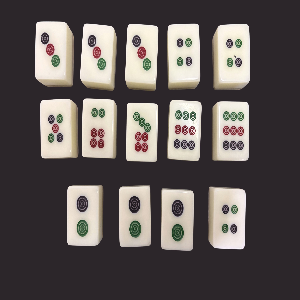

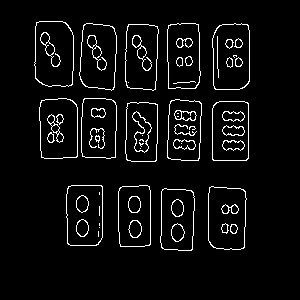

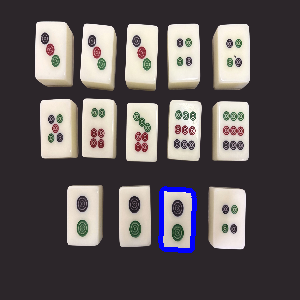

頂點數量: 4
area 1930.5


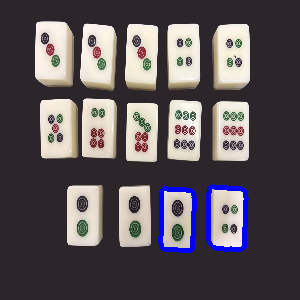

頂點數量: 4
area 2201.5


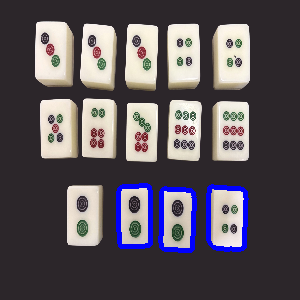

頂點數量: 4
area 1895.0


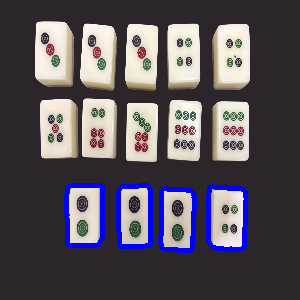

頂點數量: 4
area 2093.0


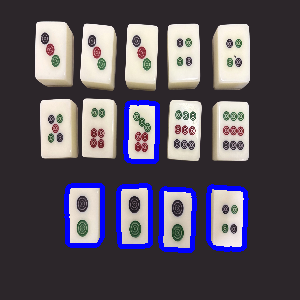

頂點數量: 4
area 1800.0


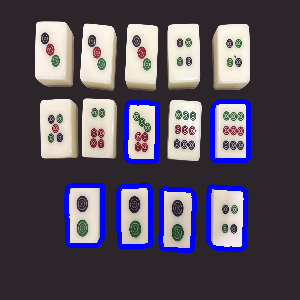

頂點數量: 4
area 2101.0


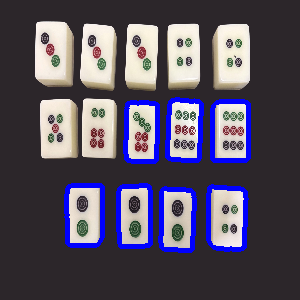

頂點數量: 4
area 1892.5


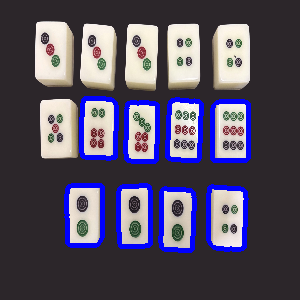

頂點數量: 4
area 1991.5


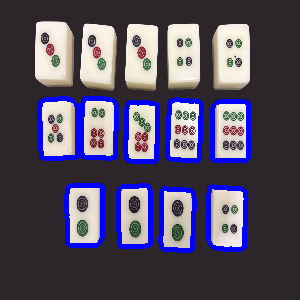

頂點數量: 4
area 2154.0


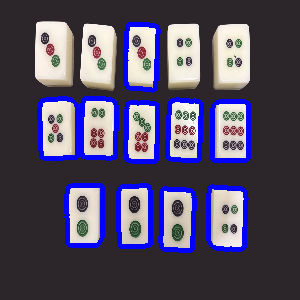

頂點數量: 4
area 1972.5


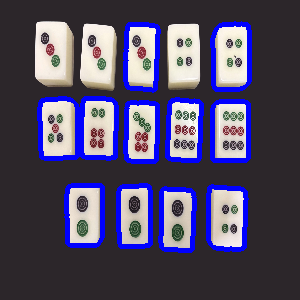

頂點數量: 4
area 2280.0


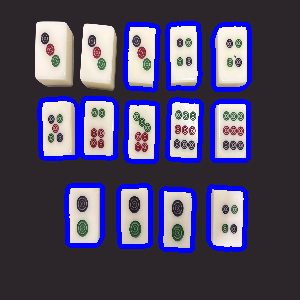

頂點數量: 4
area 2013.0


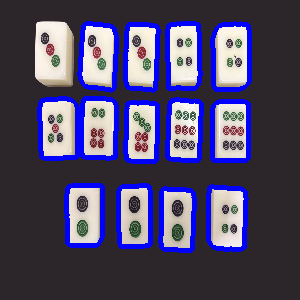

頂點數量: 4
area 2140.5


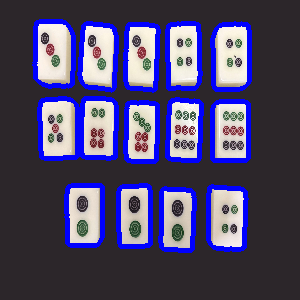

頂點數量: 4
area 2339.0
向右傾斜（左上抬高）
WL 29.274562336608895 59.07622195096772


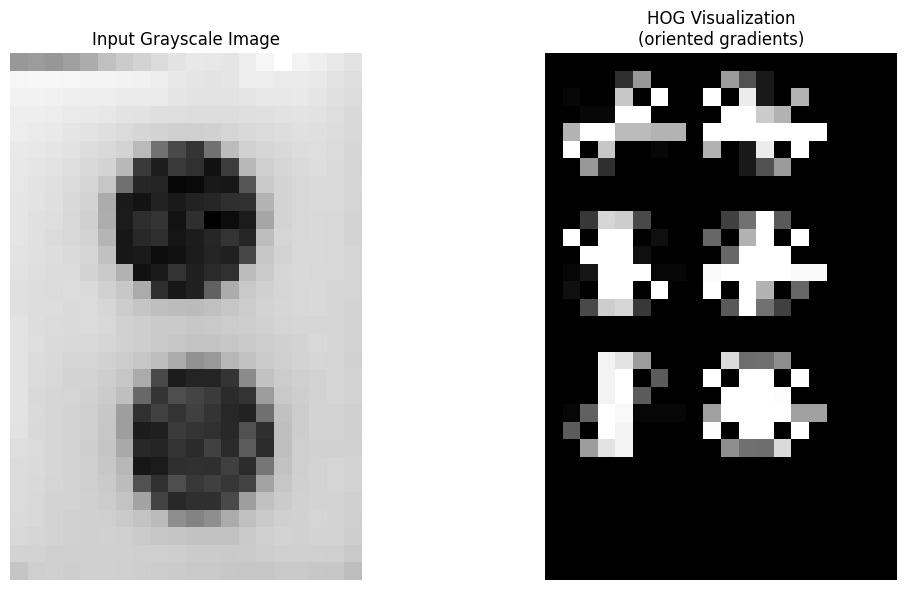

向右傾斜（左上抬高）
WL 36.22154055254967 0.0
fuck
更正：向左傾斜（右上抬高）
right_up_corner = left_up_corner
打橫兩個錯 --> y value 太接近


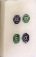

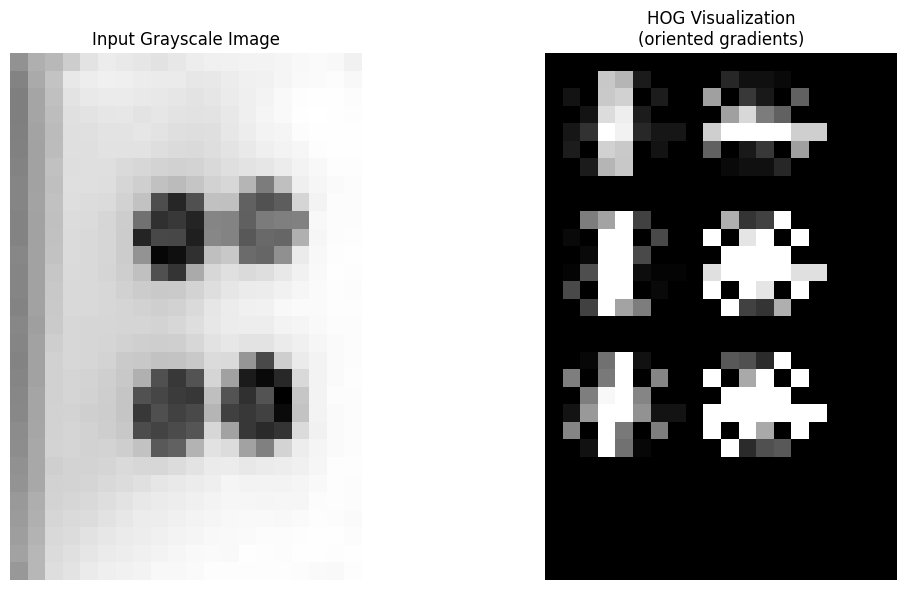

向左傾斜（右上抬高）
WL 28.160255680657446 58.008620049092706


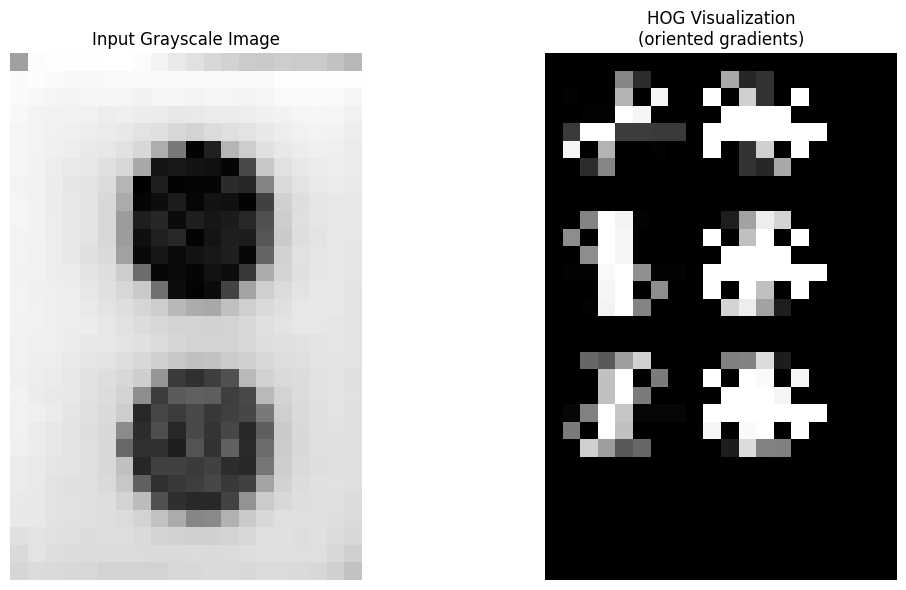

向右傾斜（左上抬高）
WL 34.0 57.0087712549569


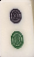

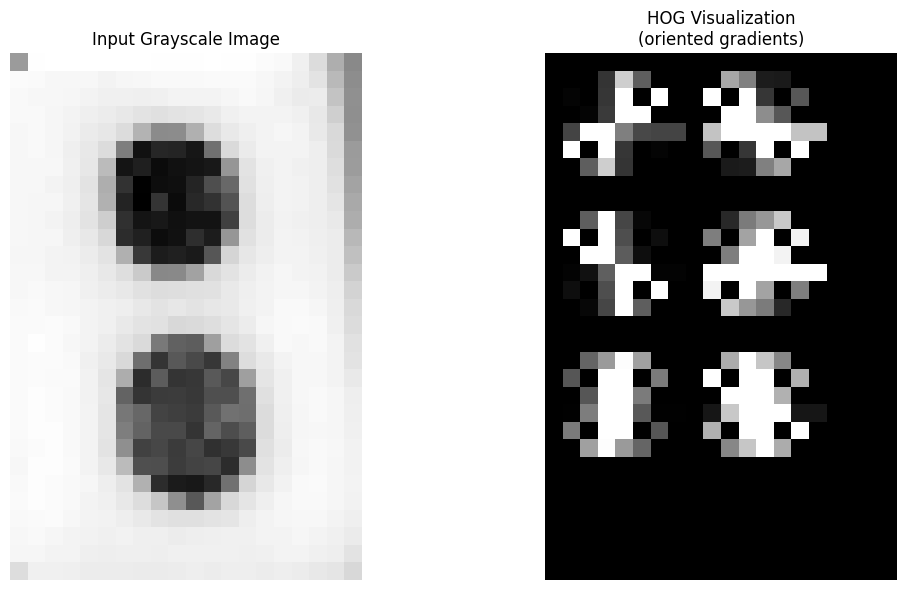

向右傾斜（左上抬高）
WL 30.01666203960727 56.00892785976178


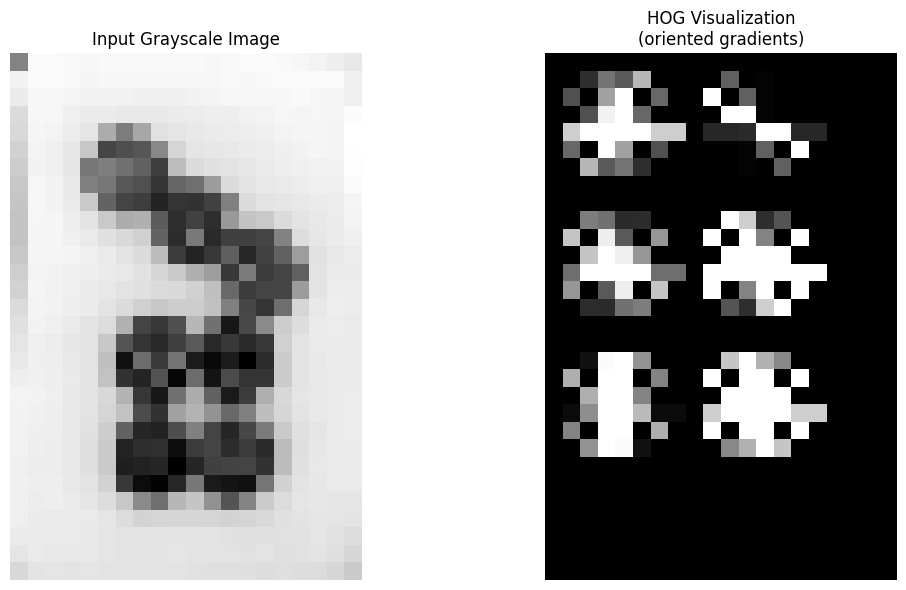

向右傾斜（左上抬高）
WL 32.01562118716424 57.14017850864661


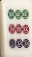

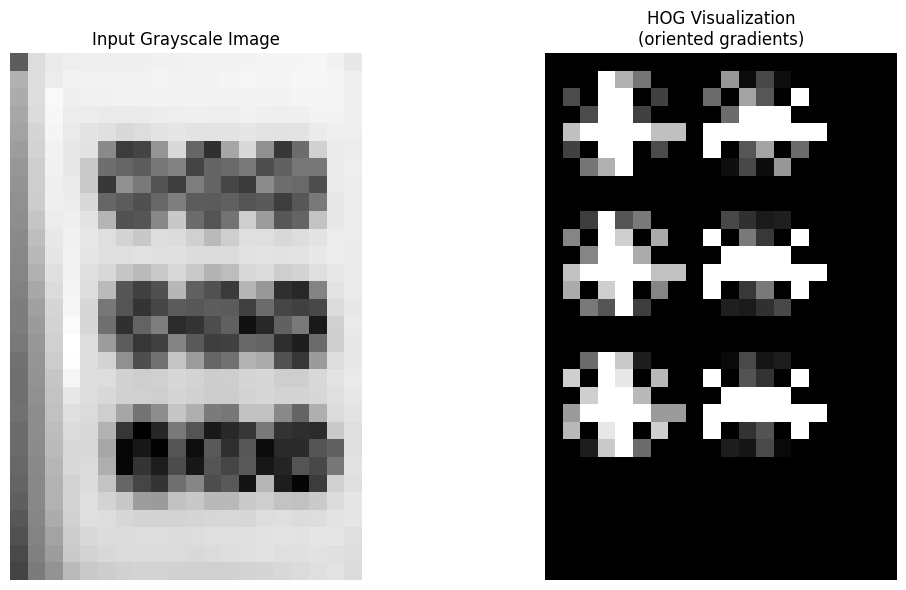

向右傾斜（左上抬高）
WL 30.14962686336267 57.14017850864661


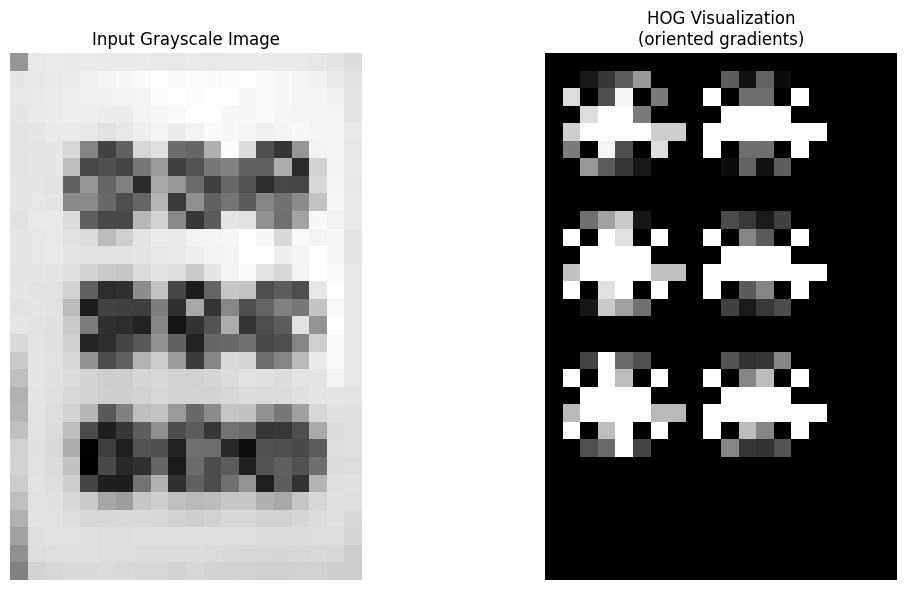

向右傾斜（左上抬高）
WL 31.25699921617557 58.034472514187634


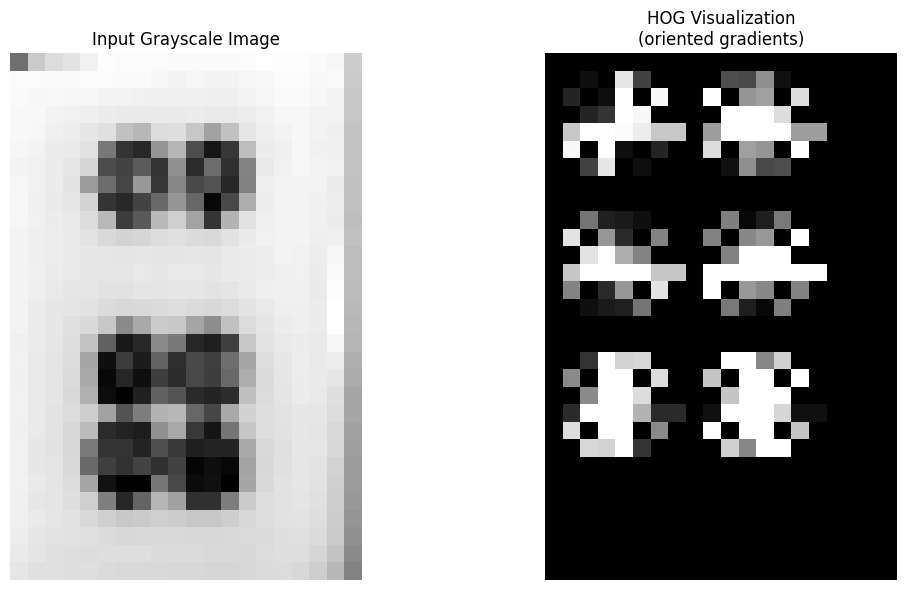

向右傾斜（左上抬高）
WL 35.22782990761707 0.0
fuck
更正：向左傾斜（右上抬高）
right_up_corner = left_up_corner
打橫兩個錯 --> y value 太接近


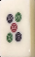

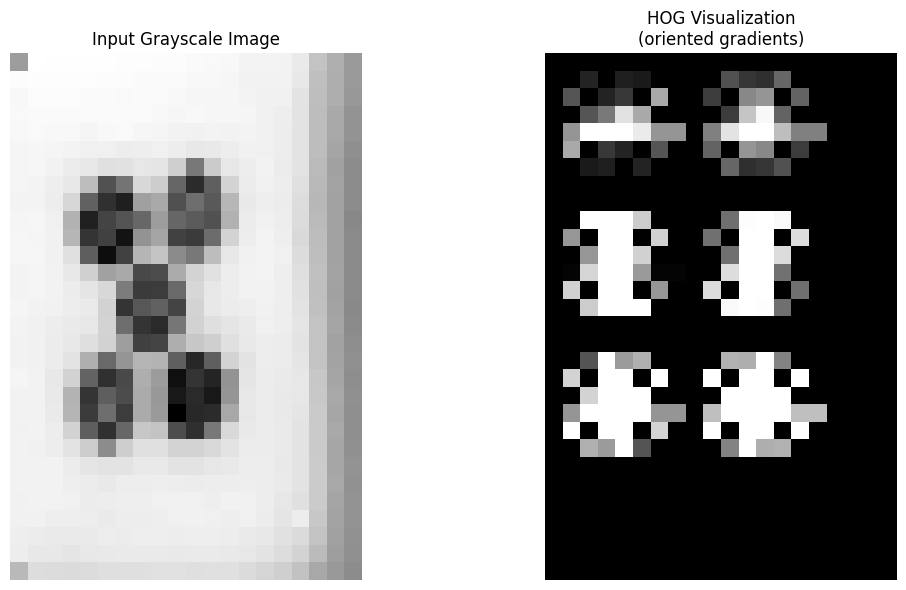

向右傾斜（左上抬高）
WL 29.068883707497267 61.032778078668514


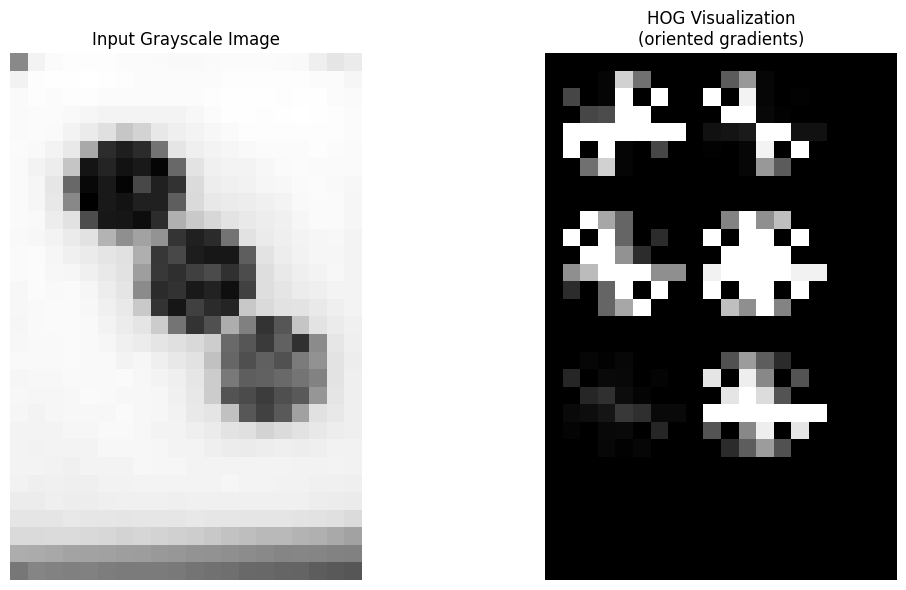

向左傾斜（右上抬高）
WL 33.95585369269929 57.0087712549569


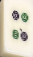

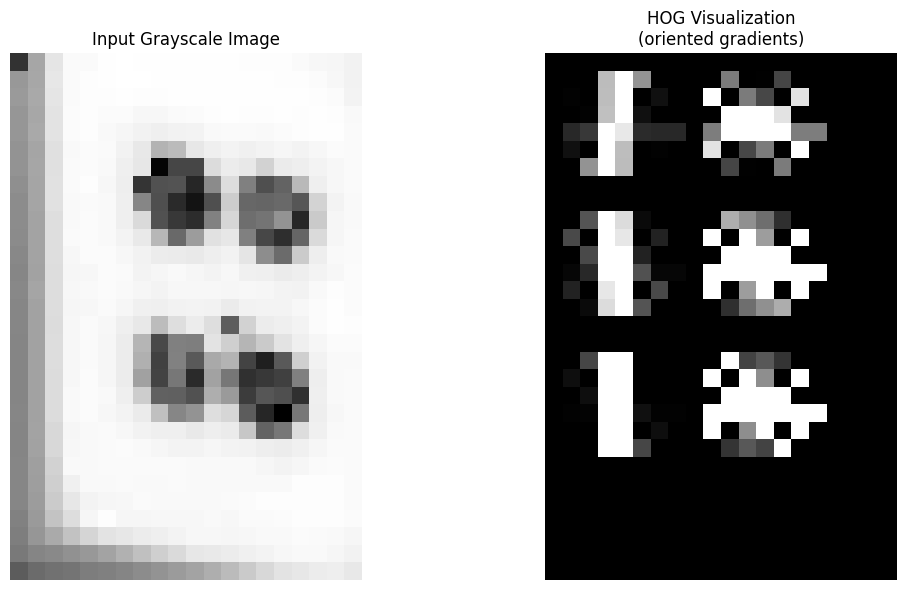

向右傾斜（左上抬高）
WL 28.0 64.03124237432849


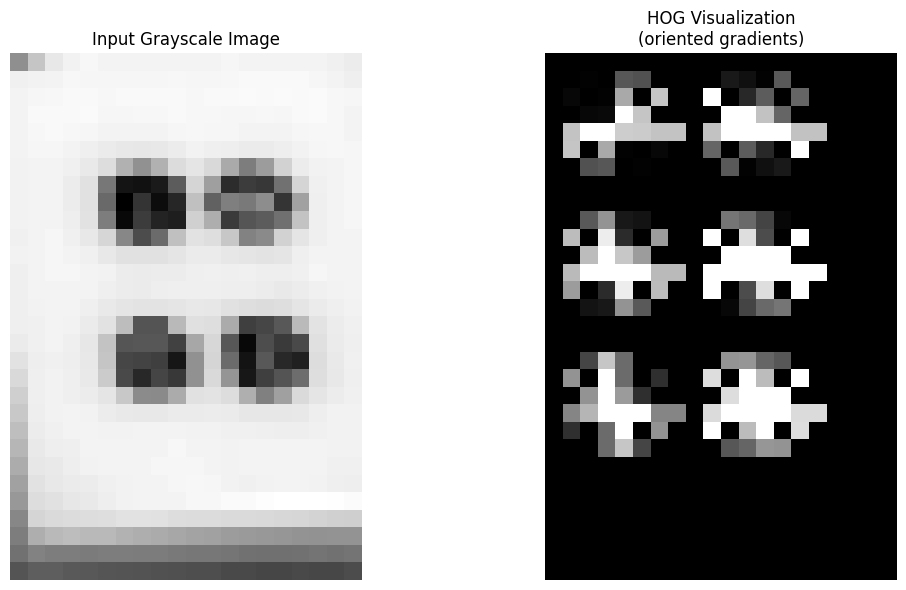

向右傾斜（左上抬高）
WL 28.442925306655784 56.32051136131489


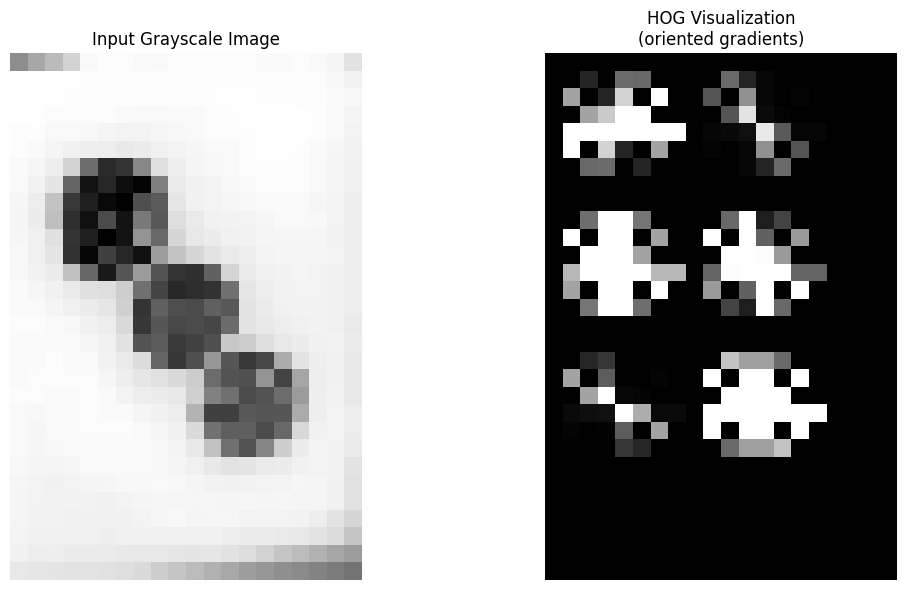

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
模型和 scaler 已成功載入！


ValueError: X has 72 features, but StandardScaler is expecting 3780 features as input.

In [24]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler #for 特徵縮放
from sklearn.svm import SVC #非線性
def read_image(file_name):
  img = cv2.imread(file_name)
  img = cv2.resize(img,(300,300))
  img2 = img.copy() #建立一個copy 去畫野上去
  if img is None:
    print("請上傳圖片或指定正確路徑")
  cv2_imshow(img)
  return(img,img2)
def Pre_process(img): #灰階轉換+blur+canny
  gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)#灰階轉換
  blur_img = cv2.GaussianBlur(gray_img,(5,5),0)#blur
  # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # 步驟2：CLAHE 局部對比增強（非常有效處理光影不均）
  # clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(16,16)) # 改成這樣（明顯減弱）
  # enhanced = clahe.apply(blur_img)  # 步驟3：可選 - 再做一次輕微模糊或中值濾波
  # enhanced = cv2.medianBlur(enhanced, 3)
  # # 現在用 enhanced 去做 Canny
  # canny = cv2.Canny(enhanced, 100,120)   # 調整這兩個閾值很重要.
  canny = cv2.Canny(blur_img,160,175) #邊緣化
  # kernel = np.ones((3,3),np.uint8)
  # canny = cv2.dilate(canny,kernel,iterations =1)
  cv2_imshow(canny)
  return(canny)
def detect_contour(canny,img2):
  vertices_4_corners = np.zeros([10000,4,1,2]) # 9 隻牌
  vertices_arr_i = 0
  vertices = np.ones([4,2])
  area_max = 0
  contours, hierarchy = cv2.findContours(canny,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
  for cnt in contours:
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt,True)
    if (area > 500) :
      cv2.drawContours(img2,cnt,-1,(255,0,0),4)
      cv2_imshow(img2)
      peri = cv2.arcLength(cnt,True)
      vertices = cv2.approxPolyDP(cnt,peri*0.06,True)
      #print(vertices)
      print("頂點數量:", len(vertices))
      print("area",area)
    if len(vertices) == 4 :
      vertices_4_corners_not_array = vertices
    if vertices_4_corners_not_array.shape == (4, 1, 2):
      vertices_4_corners[vertices_arr_i,:,:,:] = vertices_4_corners_not_array
      vertices_arr_i = vertices_arr_i +1




  # prevent the case that the outer contour is not closed
  # if (area_max <4500) and len (vertices) == 4:
  #     print("the outer contour is not closed")
  #     kernel = np.ones((3,3),np.uint8)
  #     canny = cv2.dilate(canny,kernel,iterations =1)
  #     contours, hierarchy = cv2.findContours(canny,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
  #     for cnt in contours:
  #       area = cv2.contourArea(cnt)
  #       peri = cv2.arcLength(cnt,True)
  #       if (area > 2000) and  (area > area_max):
  #         area_max = area
  #         cv2.drawContours(img2,cnt,-1,(255,0,0),4)
  #         cv2_imshow(img2)
  #         peri = cv2.arcLength(cnt,True)
  #         vertices = cv2.approxPolyDP(cnt,peri*0.09,True)
  #         #print(vertices)
  #         print("頂點數量:", len(vertices))
  #         print("area:",area )



  return (vertices_4_corners)
def sort_order(vertices):
  vertices_orderx =  np.empty([4,2])
  vertices_ordery =  np.empty([4,2])
  for i in range(4):
    vertices_orderx [i,0] = vertices[i,0,0]
    vertices_orderx [i,1] = vertices[i,0,1]
    vertices_ordery [i,0] = vertices[i,0,0]
    vertices_ordery [i,1] = vertices[i,0,1]
  vertices_orderx = vertices_orderx[np.argsort(vertices_orderx[:, 0])]
  vertices_ordery = vertices_ordery[np.argsort(vertices_ordery[:, 1])]

  return vertices_orderx,vertices_ordery
def find_four_corners(vertices,vertices_orderx,vertices_ordery):
  right_up_corner = np.empty([2])
  left_up_corner = np.empty([2])
  right_down_corner = np.empty([2])
  left_down_corner = np.empty([2])
  R_or_L = 'r'
  # 計算四個點的平均 x（中心 x）
  center_x = np.mean(vertices[:, 0, 0])
  # 找到最高點（y 最小的點）的 x
  highest_idx = np.argmin(vertices[:, 0, 1])
  highest_x = vertices[highest_idx, 0, 0]
  if highest_x <  center_x:
    print("向右傾斜（左上抬高）")
    R_or_L = 'r'
    right_down_corner[0] = vertices_ordery[3,0]    #最低 = 右下
    right_down_corner[1] = vertices_ordery[3,1]
    left_down_corner[0] = vertices_orderx[0,0]   # 最左的data ＝左下
    left_down_corner[1] = vertices_orderx[0,1]
    right_up_corner[0] = vertices_orderx[3,0]   #最右的data ＝右上
    right_up_corner[1] = vertices_orderx[3,1]
    left_up_corner[0] = vertices_ordery[0,0] #最高的data ＝左上
    left_up_corner[1] = vertices_ordery[0,1]
  else:
      print("向左傾斜（右上抬高）")
      R_or_L = 'l'
      right_down_corner[0] = vertices_orderx[3,0] #右下 --> 最右 (最大x)
      right_down_corner[1] = vertices_orderx[3,1]
      left_down_corner[0] = vertices_ordery[3,0] # 左下 --> 最下 (最大y)
      left_down_corner[1] = vertices_ordery[3,1]
      right_up_corner[0] = vertices_ordery[0,0] #最高的data ＝右上
      right_up_corner[1] = vertices_ordery[0,1]
      left_up_corner[0] = vertices_orderx[0,0] #最左= 左上
      left_up_corner[1] = vertices_orderx[0,1]
  width = math.sqrt(((left_up_corner[1] - right_up_corner[1])**2) + ((left_up_corner[0] - right_up_corner[0])**2))
  length = math.sqrt(((left_down_corner[1] - left_up_corner[1])**2) + ((left_down_corner[0] - left_up_corner[0])**2))
  print("WL",width,length)
  if width > length:
    print('fuck')
    if R_or_L == 'r':
      print("更正：向左傾斜（右上抬高）")
      right_down_corner[0] = vertices_orderx[3,0] #右下 --> 最右 (最大x)
      right_down_corner[1] = vertices_orderx[3,1]
      left_down_corner[0] = vertices_ordery[3,0] # 左下 --> 最下 (最大y)
      left_down_corner[1] = vertices_ordery[3,1]
      right_up_corner[0] = vertices_ordery[0,0] #最高的data ＝右上
      right_up_corner[1] = vertices_ordery[0,1]
      left_up_corner[0] = vertices_orderx[0,0] #最左= 左上
      left_up_corner[1] = vertices_orderx[0,1]
      R_or_L = "l"
    else:
      print("更正： 向右傾斜（左上抬高）")
      right_down_corner[0] = vertices_ordery[3,0]    #最低 = 右下
      right_down_corner[1] = vertices_ordery[3,1]
      left_down_corner[0] = vertices_orderx[0,0]   # 最左的data ＝左下
      left_down_corner[1] = vertices_orderx[0,1]
      right_up_corner[0] = vertices_orderx[3,0]   #最右的data ＝右上
      right_up_corner[1] = vertices_orderx[3,1]
      left_up_corner[0] = vertices_ordery[0,0] #最高的data ＝左上
      left_up_corner[1] = vertices_ordery[0,1]
      R_or_L = "r"




  return right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L
def check_error(right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L,vertices_orderx,vertices_ordery):
  error_LR = False #打橫兩個錯 --> y value 太接近
  error_UD = False #打直兩個錯 --> x value 太接近
  if np.array_equal(right_up_corner, left_up_corner):
      print("right_up_corner = left_up_corner")
      error_LR = True
  elif np.array_equal(right_up_corner, right_down_corner):
      print("right_up_corner = right_down_corner")
      error_UD = True
  elif np.array_equal(left_up_corner, left_down_corner):
      print("left_up_corner = left_down_corner")
      error_UD = True
  elif np.array_equal(right_down_corner, left_down_corner):
      print("right_down_corner = left_down_corner")
      error_LR = True
  if error_LR == True:
      print("打橫兩個錯 --> y value 太接近")
      # 分左右
      if vertices_orderx[0,1] > vertices_orderx[1,1]: #最左既Y  >  第二左Y （左） 向右傾斜
        left_up_corner = vertices_orderx [1,:]   #第二左Y -->左上
        left_down_corner = vertices_orderx[0,:] #最左既Y  -->左下
      else :                                     #最左既Y  ＜ 第二左Y  向左傾斜
       left_up_corner = vertices_orderx [0,:]  #最左Y -->左上
       left_down_corner = vertices_orderx[1,:] #第二左Y -->左下
      if vertices_orderx[2,1] > vertices_orderx[3,1]: #第三左既Y  >  第四左Y  （右） 向右傾斜
        right_up_corner = vertices_orderx[3,:] #第四左Y --> 右下
        right_down_corner = vertices_orderx[2,:] #第三左既Y --＞右下
      else:                                   #第三左既Y  <  第四左Y     向左傾斜
        right_up_corner = vertices_orderx[2,:] #第三左Y --> 右上
        right_down_corner = vertices_orderx[3,:] #第四左Y --> 右下
  elif error_UD == True:
      # 分上下
      print("打直兩個錯 --> x value 太接近")
      if vertices_ordery[0,0] > vertices_ordery[1,0]: #最高x > 第二高x    （上） 向左傾斜
        left_up_corner = vertices_ordery [1,:]   #第二高x -->左上
        right_up_corner = vertices_ordery[0,:] #最高x --> 右上
      else :                                    #最高x < 第二高x  向右傾斜
       right_up_corner = vertices_ordery [1,:] #第二高x -->右上
       left_up_corner = vertices_ordery[0,:] #最高x --> 左上
      if vertices_ordery[2,0] > vertices_ordery[3,0]: # 第三高x > 第四高x（下）向左傾斜
        right_down_corner = vertices_ordery[2,:] # 第三高 --> 右下
        left_down_corner = vertices_ordery[3,:] # 第四高 --> 左下
      else:                                       # 第三高x < 第四高x（下） 向右傾斜
        right_down_corner = vertices_ordery[3,:] # 第四高 --> 右下
        left_down_corner = vertices_ordery[2,:] # 第三高 --> 左下

  return right_up_corner ,left_up_corner , right_down_corner , left_down_corner

def crop (right_up_corner ,left_up_corner , right_down_corner , left_down_corner,img):
  src_pts = np.array([left_up_corner, #左上
                      right_up_corner, #右上
                      left_down_corner, #左下
                      right_down_corner], #右下
                      dtype=np.float32)
  width = math.sqrt(((src_pts[0,1] - src_pts[1,1])**2) + ((src_pts[0,0] - src_pts[1,0])**2))
  length = math.sqrt(((src_pts[2,1] - src_pts[0,1])**2) + ((src_pts[2,0] - src_pts[0,0])**2))


  dst_pts = np.array([[0,0], #左上
                      [width, 0], #右上
                      [0, length], #左下
                      [width, length]], #右下
                      dtype=np.float32)

  M = cv2.getPerspectiveTransform(src_pts, dst_pts)
  result = cv2.warpPerspective(img, M, (int(width),int(length)))
  cv2_imshow(result)
  return result
# 在主迴圈裡，crop_image = crop(...) 之後加這段

# 去黑邊函數
def remove_black_border(no_black):
    gray = cv2.cvtColor(no_black, cv2.COLOR_BGR2GRAY)
    # 用低閾值二值化，抓出非黑區域
    _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    # 找非零像素
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        # 加一點 padding 避免切太緊
        padding = 5
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(w + 2*padding, no_black.shape[1] - x)
        h = min(h + 2*padding, no_black.shape[0] - y)
        return no_black[y:y+h, x:x+w]
    return no_black

def HOG (result):
  result = cv2.resize(result,(20,30))
  image_gray = cv2.cvtColor(result,cv2.COLOR_BGR2GRAY)
  # Compute HOG + visualization
  fd, hog_image = hog(
      image_gray,
      orientations=9,              # number of orientation bins (classic = 9)
      pixels_per_cell=(8, 8),      # cell size (classic = 8×8 pixels)
      cells_per_block=(2, 2),      # block size (classic = 2×2 cells → 4 cells/block)
      block_norm='L2-Hys',         # most common & robust normalization
      visualize=True,              # return visualization image
      transform_sqrt=False,        # optional gamma compression (usually False)
      feature_vector=True)          # return flattened vector (default)
  return fd, hog_image,image_gray
def display_hog_result(image_gray,hog_image):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  ax1.axis('off')
  ax1.imshow(image_gray, cmap=plt.cm.gray)
  ax1.set_title('Input Grayscale Image')
  # Optional: rescale hog_image for better visibility (sometimes very dark)
  hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
  ax2.axis('off')
  ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
  ax2.set_title('HOG Visualization\n(oriented gradients)')
  plt.tight_layout()
  plt.show()

def get_features(file_name):
  img,img2 = read_image(file_name)
  canny = Pre_process(img)
  vertices = detect_contour(canny,img2)
  vertices_orderx,vertices_ordery = sort_order(vertices)
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner ,R_or_L= find_four_corners(vertices,vertices_orderx,vertices_ordery)
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner = check_error(right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L,vertices_orderx,vertices_ordery)
  crop_image = crop (right_up_corner ,left_up_corner , right_down_corner , left_down_corner,img)
  no_black = remove_black_border(crop_image)
  fd, hog_image ,image_gray = HOG (no_black)
  display_hog_result(image_gray,hog_image)
  return fd

img,img2 = read_image("testing_13tungji_7.jpg")
canny =Pre_process(img)
vertices_4_corners = detect_contour(canny,img2)
x = np.empty([13,72])
for i in range(13):
  vertices_orderx,vertices_ordery = sort_order(vertices_4_corners[i,:,:,:])
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner ,R_or_L= find_four_corners(vertices_4_corners[i,:,:,:],vertices_orderx,vertices_ordery)
  right_up_corner ,left_up_corner , right_down_corner , left_down_corner = check_error(right_up_corner ,left_up_corner , right_down_corner , left_down_corner,R_or_L,vertices_orderx,vertices_ordery)
  crop_image = crop (right_up_corner ,left_up_corner , right_down_corner , left_down_corner,img)
  fd, hog_image ,image_gray = HOG (crop_image)
  display_hog_result(image_gray,hog_image)
  x[i,:] = fd

from google.colab import drive
drive.mount('/content/drive')

# 2. 定義相同路徑
save_path = '/content/drive/My Drive/my_model/'   # 跟上面一樣

# 3. 載入模型和 scaler
import joblib

clf_loaded    = joblib.load(save_path + 'clf_model.joblib')
scaler_loaded = joblib.load(save_path + 'scaler.joblib')

print("模型和 scaler 已成功載入！")

# 4. 現在就可以用來預測新資料（不用再訓練）
# 假設你有 get_features() 函數
for i in range(13):
  new_data = x[i,:]
  new_data_2d = new_data.reshape(1, -1)               # 轉成 2D

  new_data_scaled = scaler_loaded.transform(new_data_2d)  # 只 transform
  prediction = clf_loaded.predict(new_data_scaled)
  print("預測結果：", prediction)



